<a href="https://colab.research.google.com/github/teja01721/AML/blob/main/ML_LAB_Assinment03_0809_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question-1:
 Create a dataset containing temperature and electricity consumption. Train a simple linear regression model. Divide the data into training and testing sets. Print the slope and intercept. Calculate MAE, MSE, RMSE, and (R^2). Plot the regression line. Plot residuals. Add another input feature and train a multiple regression model. Compare simple and multiple regression performance. Investigate the effect of adding an outlier.

In [ ]:
import pandas as pd

data = {
    "Temperature": [18, 20, 22, 24, 26, 28, 30, 32, 34, 36,
                    19, 21, 23, 25, 27, 29, 31, 33, 35, 37],

    "Humidity": [40, 42, 45, 43, 48, 50, 52, 55, 57, 60,
                 41, 44, 46, 47, 49, 51, 54, 56, 58, 62],

    "Electricity_Consumption": [210, 225, 235, 250, 270, 290, 310, 335, 360, 390,
                                218, 230, 242, 260, 280, 300, 325, 345, 375, 405]
}

df = pd.DataFrame(data)

print(df)


    Temperature  Humidity  Electricity_Consumption
0            18        40                      210
1            20        42                      225
2            22        45                      235
3            24        43                      250
4            26        48                      270
5            28        50                      290
6            30        52                      310
7            32        55                      335
8            34        57                      360
9            36        60                      390
10           19        41                      218
11           21        44                      230
12           23        46                      242
13           25        47                      260
14           27        49                      280
15           29        51                      300
16           31        54                      325
17           33        56                      345
18           35        58      

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np


In [ ]:
X = df[["Temperature"]]
y = df["Electricity_Consumption"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)


LinearRegression()

In [ ]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)


Slope: 10.622459614382493
Intercept: -0.3191766545076007


In [ ]:
print(
    f"Equation: Electricity = "
    f"{model.intercept_:.2f} + "
    f"{model.coef_[0]:.2f} * Temperature"
)


Equation: Electricity = -0.32 + 10.62 * Temperature


In [ ]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)


Predictions:
[190.8850964  350.22199062 307.73215216 212.13001563]


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison)


   Actual   Predicted
0     210  190.885096
1     345  350.221991
2     300  307.732152
3     225  212.130016


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)
rmse = np.sqrt(mse)

print("RMSE:", rmse)
r2 = r2_score(y_test, y_pred)

print("R²:", r2)


MAE: 11.234757686294948
MSE: 154.51785004376046
RMSE: 12.43052090798131
R²: 0.9491299259115192


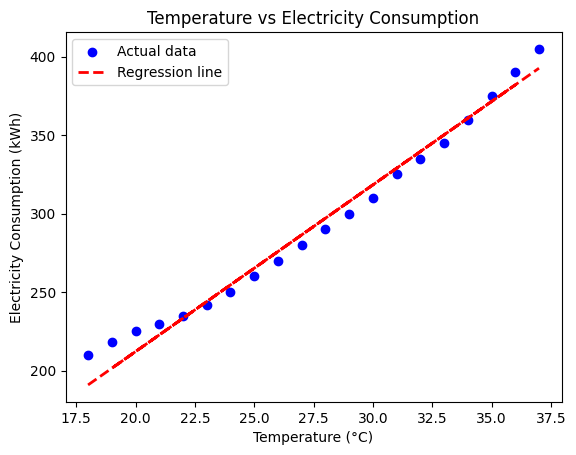

In [ ]:
plt.scatter(
    X,
    y,
    color="blue",
    label="Actual data"
)

plt.plot(
    X,
    model.predict(X),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Regression line"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Electricity Consumption (kWh)")

plt.title("Temperature vs Electricity Consumption")

plt.legend()
plt.show()


In [ ]:
residuals = y_test - y_pred

print(residuals)


0     19.114904
17    -5.221991
15    -7.732152
1     12.869984
Name: Electricity_Consumption, dtype: float64


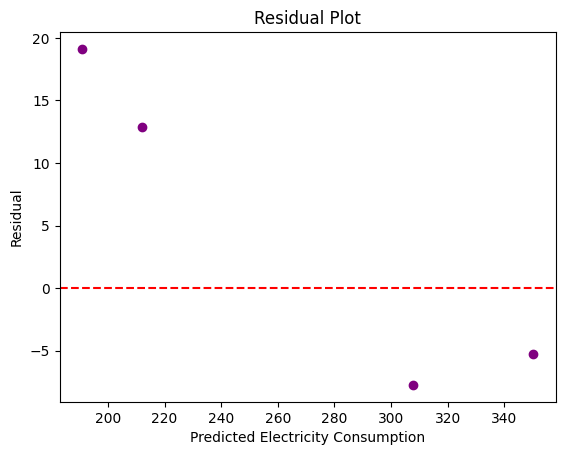

In [ ]:
plt.scatter(
    y_pred,
    residuals,
    color="purple"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Electricity Consumption")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()


In [ ]:
#Create the multiple regression model
X_multiple = df[
    ["Temperature", "Humidity"]
]

y = df["Electricity_Consumption"]


In [ ]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
multiple_model = LinearRegression()

multiple_model.fit(
    X_train_m,
    y_train_m
)


LinearRegression()

In [ ]:
print("Intercept:", multiple_model.intercept_)

print(
    "Temperature coefficient:",
    multiple_model.coef_[0]
)

print(
    "Humidity coefficient:",
    multiple_model.coef_[1]
)


Intercept: -75.04656481702943
Temperature coefficient: 6.296684405644581
Humidity coefficient: 3.874521645539346


In [ ]:
y_pred_multiple = multiple_model.predict(X_test_m)


In [ ]:
mae_multiple = mean_absolute_error(
    y_test_m,
    y_pred_multiple
)

mse_multiple = mean_squared_error(
    y_test_m,
    y_pred_multiple
)

rmse_multiple = np.sqrt(mse_multiple)

r2_multiple = r2_score(
    y_test_m,
    y_pred_multiple
)


In [ ]:
print("\n===== MULTIPLE LINEAR REGRESSION =====")

print("MAE:", mae_multiple)
print("MSE:", mse_multiple)
print("RMSE:", rmse_multiple)
print("R²:", r2_multiple)



===== MULTIPLE LINEAR REGRESSION =====
MAE: 9.4958667184884
MSE: 114.54158964422996
RMSE: 10.70241045952873
R²: 0.9622908346850272


In [ ]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],

    "Simple Regression": [
        mae,
        mse,
        rmse,
        r2
    ],

    "Multiple Regression": [
        mae_multiple,
        mse_multiple,
        rmse_multiple,
        r2_multiple
    ]
})

print(comparison)


  Metric  Simple Regression  Multiple Regression
0    MAE          11.234758             9.495867
1    MSE         154.517850           114.541590
2   RMSE          12.430521            10.702410
3     R²           0.949130             0.962291


# Investigate the effect of an outlier

In [ ]:
df_outlier = df.copy()

new_row = pd.DataFrame({
    "Temperature": [30],
    "Humidity": [52],
    "Electricity_Consumption": [800]
})

df_outlier = pd.concat(
    [df_outlier, new_row],
    ignore_index=True
)

print(df_outlier.tail())


    Temperature  Humidity  Electricity_Consumption
16           31        54                      325
17           33        56                      345
18           35        58                      375
19           37        62                      405
20           30        52                      800


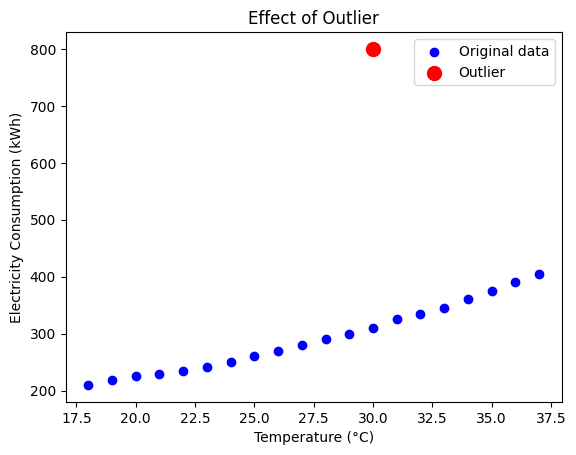

In [ ]:
plt.scatter(
    df["Temperature"],
    df["Electricity_Consumption"],
    color="blue",
    label="Original data"
)

plt.scatter(
    30,
    800,
    color="red",
    s=100,
    label="Outlier"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Electricity Consumption (kWh)")

plt.title("Effect of Outlier")

plt.legend()
plt.show()


In [ ]:
X_outlier = df_outlier[["Temperature"]]

y_outlier = df_outlier[
    "Electricity_Consumption"
]

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_outlier,
    y_outlier,
    test_size=0.2,
    random_state=42
)

model_outlier = LinearRegression()

model_outlier.fit(
    X_train_o,
    y_train_o
)

y_pred_outlier = model_outlier.predict(X_test_o)


In [ ]:
mae_outlier = mean_absolute_error(
    y_test_o,
    y_pred_outlier
)

mse_outlier = mean_squared_error(
    y_test_o,
    y_pred_outlier
)

rmse_outlier = np.sqrt(mse_outlier)

r2_outlier = r2_score(
    y_test_o,
    y_pred_outlier
)

print("\n===== WITH OUTLIER =====")

print("Slope:", model_outlier.coef_[0])
print("Intercept:", model_outlier.intercept_)

print("MAE:", mae_outlier)
print("MSE:", mse_outlier)
print("RMSE:", rmse_outlier)
print("R²:", r2_outlier)



===== WITH OUTLIER =====
Slope: 12.919877163595755
Intercept: -34.204075935231685
MAE: 29.029759910664417
MSE: 1205.811977671718
RMSE: 34.7248034936372
R²: 0.6763789646613747


In [ ]:
print("\n===== OUTLIER COMPARISON =====")

print("Original slope:",
      model.coef_[0])

print("Outlier slope:",
      model_outlier.coef_[0])

print()

print("Original intercept:",
      model.intercept_)

print("Outlier intercept:",
      model_outlier.intercept_)



===== OUTLIER COMPARISON =====
Original slope: 10.622459614382493
Outlier slope: 12.919877163595755

Original intercept: -0.3191766545076007
Outlier intercept: -34.204075935231685


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


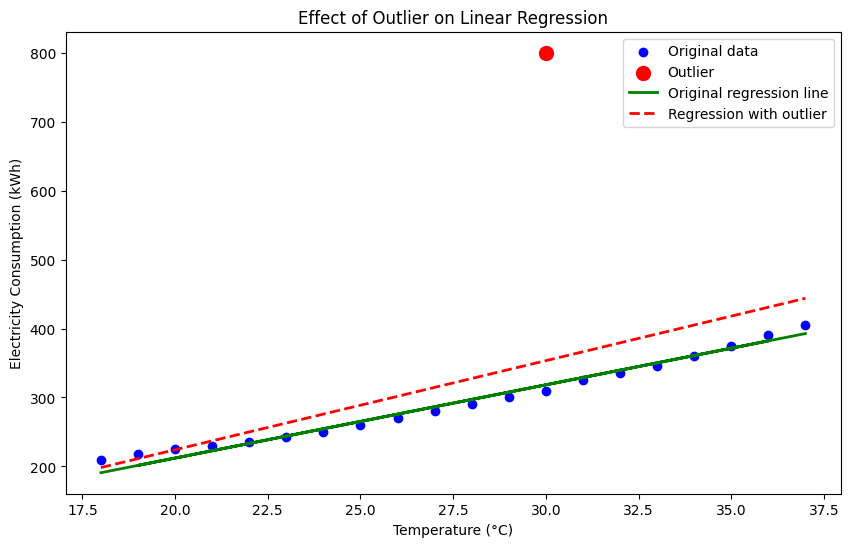

In [ ]:
plt.figure(figsize=(10, 6))

# Original data
plt.scatter(
    df["Temperature"],
    df["Electricity_Consumption"],
    color="blue",
    label="Original data"
)

# Outlier
plt.scatter(
    30,
    800,
    color="red",
    s=100,
    label="Outlier"
)

# Original regression line
plt.plot(
    X,
    model.predict(X),
    color="green",
    linewidth=2,
    label="Original regression line"
)

# Regression line with outlier
X_range = np.linspace(
    df_outlier["Temperature"].min(),
    df_outlier["Temperature"].max(),
    100
).reshape(-1, 1)

plt.plot(
    X_range,
    model_outlier.predict(X_range),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Regression with outlier"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Electricity Consumption (kWh)")

plt.title("Effect of Outlier on Linear Regression")

plt.legend()

plt.show()


# Question 2


In [ ]:
import pandas as pd

# Create the dataset
data = {
    'Hours_Studied': [2, 4, 6, 8, 10],
    'Classes_Attended': [3, 4, 5, 6, 8],
    'Final_Score': [65, 70, 75, 85, 95]
}

df = pd.DataFrame(data)

print(df)


   Hours_Studied  Classes_Attended  Final_Score
0              2                 3           65
1              4                 4           70
2              6                 5           75
3              8                 6           85
4             10                 8           95


In [ ]:
X = df[['Hours_Studied', 'Classes_Attended']]


In [ ]:
y = df['Final_Score']


In [ ]:
import statsmodels.api as sm
X = sm.add_constant(X)


In [ ]:
#create OLS MODEL
model = sm.OLS(y, X)

results = model.fit()


In [ ]:
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:            Final_Score   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     76.33
Date:                Tue, 08 Sep 2026   Prob (F-statistic):             0.0129
Time:                        11:09:38   Log-Likelihood:                -8.1084
No. Observations:                   5   AIC:                             22.22
Df Residuals:                       2   BIC:                             21.05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               47.5000      5.303  

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [ ]:
print("Coefficients:")
print(results.params)


Coefficients:
const               47.50
Hours_Studied        0.75
Classes_Attended     5.00
dtype: float64


In [ ]:
print("Intercept:", results.params['const'])

print(
    "Hours Studied coefficient:",
    results.params['Hours_Studied']
)

print(
    "Classes Attended coefficient:",
    results.params['Classes_Attended']
)


Intercept: 47.49999999999997
Hours Studied coefficient: 0.7499999999999895
Classes Attended coefficient: 5.000000000000021


In [ ]:
new_student = pd.DataFrame({
    'const': [1],
    'Hours_Studied': [7],
    'Classes_Attended': [5]
})


In [ ]:
prediction = results.predict(new_student)

print("Predicted Final Score:", prediction.iloc[0])



Predicted Final Score: 77.75


In [ ]:
X = sm.add_constant(X)


# Question-3

In [ ]:
import pandas as pd

data = {
    'Study_Hours': [
        5, 8, 3, 10, 7, 4, 6, 9, 2, 11,
        5, 7, 8, 3, 10, 6, 4, 9, 12, 5
    ],

    'Attendance': [
        75, 90, 65, 95, 85, 70, 80, 92, 60, 98,
        78, 88, 91, 68, 94, 82, 72, 89, 99, 76
    ],

    'Assignment_Average': [
        70, 85, 60, 92, 80, 65, 75, 88, 55, 95,
        72, 84, 87, 62, 90, 78, 68, 86, 97, 73
    ],

    'Internal_Exam': [
        65, 82, 55, 90, 78, 60, 70, 85, 50, 94,
        68, 80, 83, 58, 88, 75, 63, 84, 96, 70
    ],

    'Sleep_Hours': [
        6, 7, 5, 8, 7, 6, 7, 8, 5, 8,
        6, 7, 8, 5, 7, 7, 6, 8, 8, 6
    ],

    'Final_Mark': [
        68, 84, 58, 94, 81, 64, 74, 88, 52, 96,
        71, 83, 86, 60, 91, 77, 67, 87, 98, 73
    ]
}

df = pd.DataFrame(data)

print(df)


    Study_Hours  Attendance  Assignment_Average  Internal_Exam  Sleep_Hours  \
0             5          75                  70             65            6   
1             8          90                  85             82            7   
2             3          65                  60             55            5   
3            10          95                  92             90            8   
4             7          85                  80             78            7   
5             4          70                  65             60            6   
6             6          80                  75             70            7   
7             9          92                  88             85            8   
8             2          60                  55             50            5   
9            11          98                  95             94            8   
10            5          78                  72             68            6   
11            7          88                  84     

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [ ]:
print(df.describe())


       Study_Hours  Attendance  Assignment_Average  Internal_Exam  \
count    20.000000   20.000000           20.000000      20.000000   
mean      6.700000   82.350000           78.100000      74.700000   
std       2.867238   11.499542           12.216899      13.385381   
min       2.000000   60.000000           55.000000      50.000000   
25%       4.750000   74.250000           69.500000      64.500000   
50%       6.500000   83.500000           79.000000      76.500000   
75%       9.000000   91.250000           87.250000      84.250000   
max      12.000000   99.000000           97.000000      96.000000   

       Sleep_Hours  Final_Mark  
count    20.000000   20.000000  
mean      6.750000   77.600000  
std       1.069924   13.315602  
min       5.000000   52.000000  
25%       6.000000   67.750000  
50%       7.000000   79.000000  
75%       8.000000   87.250000  
max       8.000000   98.000000  


In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Study_Hours         20 non-null     int64
 1   Attendance          20 non-null     int64
 2   Assignment_Average  20 non-null     int64
 3   Internal_Exam       20 non-null     int64
 4   Sleep_Hours         20 non-null     int64
 5   Final_Mark          20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB
None


In [ ]:
print(df.isnull().sum())


Study_Hours           0
Attendance            0
Assignment_Average    0
Internal_Exam         0
Sleep_Hours           0
Final_Mark            0
dtype: int64


In [ ]:
print(df.isnull().any())


Study_Hours           False
Attendance            False
Assignment_Average    False
Internal_Exam         False
Sleep_Hours           False
Final_Mark            False
dtype: bool


In [ ]:
df = df.dropna()


In [ ]:
correlation = df.corr()

print(correlation)


                    Study_Hours  Attendance  Assignment_Average  \
Study_Hours            1.000000    0.978664            0.983553   
Attendance             0.978664    1.000000            0.997757   
Assignment_Average     0.983553    0.997757            1.000000   
Internal_Exam          0.986283    0.995046            0.998253   
Sleep_Hours            0.917875    0.935753            0.940198   
Final_Mark             0.985110    0.995001            0.998372   

                    Internal_Exam  Sleep_Hours  Final_Mark  
Study_Hours              0.986283     0.917875    0.985110  
Attendance               0.995046     0.935753    0.995001  
Assignment_Average       0.998253     0.940198    0.998372  
Internal_Exam            1.000000     0.931624    0.998567  
Sleep_Hours              0.931624     1.000000    0.938353  
Final_Mark               0.998567     0.938353    1.000000  


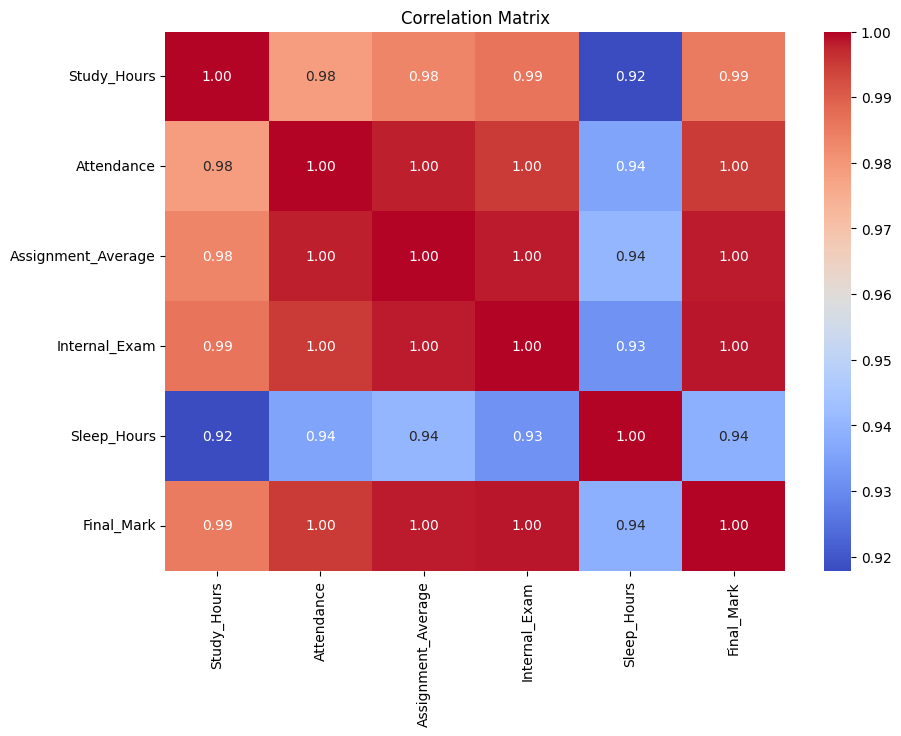

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()


In [ ]:
X = df[
    [
        'Study_Hours',
        'Attendance',
        'Assignment_Average',
        'Internal_Exam',
        'Sleep_Hours'
    ]
]


In [ ]:
y = df['Final_Mark']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (16, 5)
Testing data: (4, 5)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
comparison = pd.DataFrame({
    'Actual Mark': y_test.values,
    'Predicted Mark': y_pred
})

print(comparison)


   Actual Mark  Predicted Mark
0           68       68.297167
1           87       86.925057
2           77       78.049244
3           84       84.933532


In [ ]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)


MAE: 0.5887211781077148


In [ ]:
mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

print("RMSE:", rmse)


RMSE: 0.7187346178419168


In [ ]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R²:", r2)


R²: 0.9903443093292642


In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1)
    / (n - p - 1)
)

print("Adjusted R²:", adjusted_r2)


Adjusted R²: 1.0144835360061037


In [ ]:
print("\n===== MODEL PERFORMANCE =====")

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)



===== MODEL PERFORMANCE =====
MAE: 0.5887211781077148
RMSE: 0.7187346178419168
R²: 0.9903443093292642
Adjusted R²: 1.0144835360061037


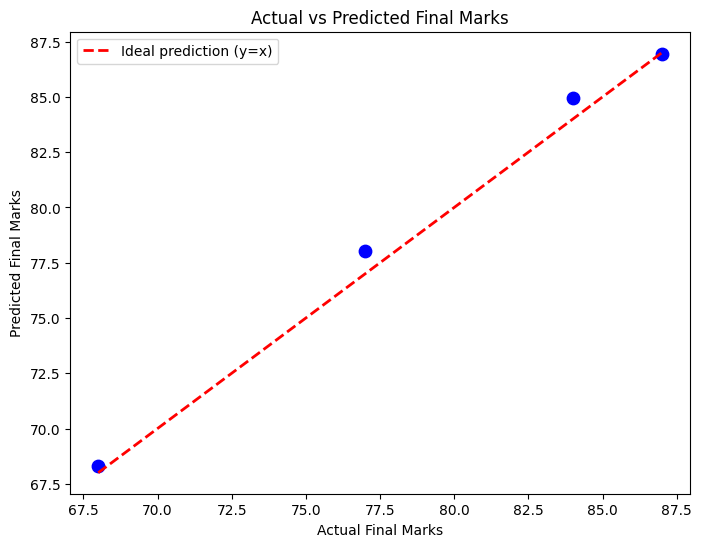

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    color='blue',
    s=80
)

# Ideal prediction line
min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Ideal prediction (y=x)'
)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")

plt.title(
    "Actual vs Predicted Final Marks"
)

plt.legend()

plt.show()


In [ ]:
residuals = y_test - y_pred


In [ ]:
print(residuals)


0    -0.297167
17    0.074943
15   -1.049244
1    -0.933532
Name: Final_Mark, dtype: float64


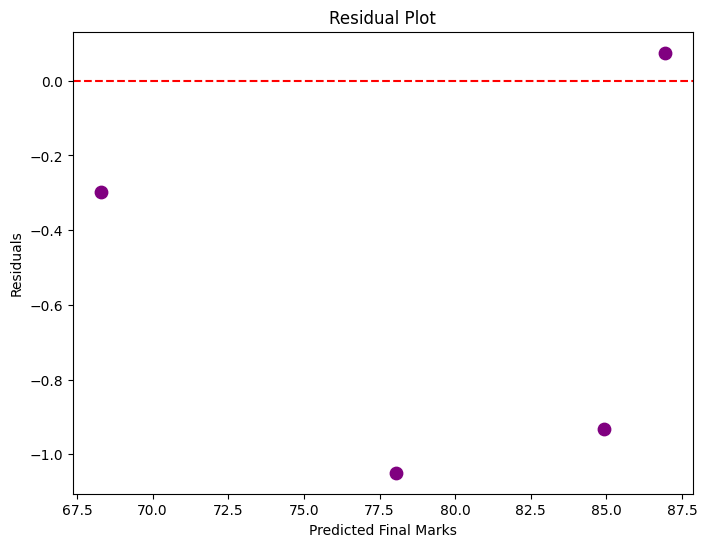

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    color='purple',
    s=80
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Final Marks")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()


In [ ]:
print("Intercept:", model.intercept_)

for feature, coefficient in zip(
    X.columns,
    model.coef_
):
    print(feature, ":", coefficient)


Intercept: -1.7585852970102422
Study_Hours : -0.12618963810000192
Attendance : -0.05172396777409216
Assignment_Average : 0.45475345336355355
Internal_Exam : 0.623883557745764
Sleep_Hours : 0.3634708318666754
